# MoCap Data Exploreation (Converted 3JS Format)

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import ijson
import numpy as np 
import matplotlib.pyplot as plt

from src.utils import print_json_structure

---
## Load & Re-Save Data

Re-save each clip as separated npz file instead of one large json for quick load.

In [ ]:
# DATA_PATH = "data/justsigns-recorder.animation_clips.json"

# clip_count = 0

# with open(DATA_PATH, "rb") as f:
#     for i, clip in enumerate(ijson.items(f, "item")):
#         sys.stdout.write(f"\rprocessing clip {i} ...")
#         sys.stdout.flush()
#         np.savez_compressed(f"data/npz/clip_{i}.npz", clip=clip, allow_pickle=True)
#         clip_count += 1

# print(f"\nfinished: {clip_count} saved as separate npz's")

processing clip 482 ...
finished: 483 saved as separate npz's


for the record: the above cell took 6m 2.1s to finish

---
## Clip Structure

In [3]:
CLIP_IDX = 72

data = np.load(f"data/npz/clip_{CLIP_IDX}.npz", allow_pickle=True)
clip = data["clip"].item()

In [4]:
print_json_structure(clip)

_id: 
    $oid: str
animationClip: 
    name: str
    duration: Decimal
    tracks: list of dict
    uuid: str
    blendMode: int
recordDate: int


In [5]:
anim = clip["animationClip"]

clip_name = anim["name"]
clip_duration = anim["duration"]
tracks = anim["tracks"]

print(f"name        = {clip_name}")
print(f"duration    = {clip_duration}")
print(f"# of tracks = {len(tracks)}")
print("\ntrack structure:")
print_json_structure(tracks[0], level=1)

name        = เจ็บที่คาง-1726388701745
duration    = 6.479800000011913
# of tracks = 671

track structure:
    name: str
    times: list of int
    values: list of Decimal
    type: str


In [20]:
# there are 2 types of track: quaternion and morphTargetInfluences

quat_names = []
morph_names = []
null_names = []

for track in tracks:
    print(track["name"])
    if "quaternion" in track["name"]:
        quat_names.append(track["name"])
    elif "morphTargetInfluences" in track["name"]:
        morph_names.append(track["name"])
    else:
        null_names.append(track["name"])

print(f"{len(quat_names)} quaternion tracks")
print(f"{len(morph_names)} morphTargetInfluences tracks")
print(f"{len(null_names)} others")

Alex_body_1.morphTargetInfluences[19]
Alex_body_1.morphTargetInfluences[38]
Alex_body_1.morphTargetInfluences[41]
Alex_body_1.morphTargetInfluences[15]
Alex_body_1.morphTargetInfluences[17]
Alex_body_1.morphTargetInfluences[28]
Alex_body_1.morphTargetInfluences[27]
Alex_body_1.morphTargetInfluences[1]
Alex_body_1.morphTargetInfluences[8]
Alex_body_1.morphTargetInfluences[2]
Alex_body_1.morphTargetInfluences[48]
Alex_body_1.morphTargetInfluences[18]
Alex_body_1.morphTargetInfluences[23]
Alex_body_1.morphTargetInfluences[24]
Alex_body_1.morphTargetInfluences[36]
Alex_body_1.morphTargetInfluences[22]
Alex_body_1.morphTargetInfluences[37]
Alex_body_1.morphTargetInfluences[21]
Alex_body_1.morphTargetInfluences[35]
Alex_body_1.morphTargetInfluences[32]
Alex_body_1.morphTargetInfluences[20]
Alex_body_1.morphTargetInfluences[31]
Alex_body_1.morphTargetInfluences[34]
Alex_body_1.morphTargetInfluences[33]
Alex_body_1.morphTargetInfluences[40]
Alex_body_1.morphTargetInfluences[30]
Alex_body_1.mor

note:
- 47 quaternion tracks
- 624 morphTargetInfluences tracks
- some clips does not have morphTargetInfluences tracks (no face tracking)

In [7]:
quat_names

['rootx.quaternion',
 'spine_01x.quaternion',
 'spine_02x.quaternion',
 'neckx.quaternion',
 'headx.quaternion',
 'shoulderr.quaternion',
 'arm_stretchr.quaternion',
 'forearm_stretchr.quaternion',
 'handr.quaternion',
 'thumb1r.quaternion',
 'thumb2r.quaternion',
 'index1r.quaternion',
 'index2r.quaternion',
 'index3r.quaternion',
 'middle1r.quaternion',
 'middle2r.quaternion',
 'middle3r.quaternion',
 'ring1r.quaternion',
 'ring2r.quaternion',
 'ring3r.quaternion',
 'pinky1r.quaternion',
 'pinky2r.quaternion',
 'pinky3r.quaternion',
 'shoulderl.quaternion',
 'arm_stretchl.quaternion',
 'forearm_stretchl.quaternion',
 'handl.quaternion',
 'thumb1l.quaternion',
 'thumb2l.quaternion',
 'index1l.quaternion',
 'index2l.quaternion',
 'index3l.quaternion',
 'middle1l.quaternion',
 'middle2l.quaternion',
 'middle3l.quaternion',
 'ring1l.quaternion',
 'ring2l.quaternion',
 'ring3l.quaternion',
 'pinky1l.quaternion',
 'pinky2l.quaternion',
 'pinky3l.quaternion',
 'thigh_stretchl.quaternion',
 

---
## Exploring Values Properties

In [8]:
# checking frames count consistency

N_TRACKS = len(tracks)

n_frames = np.empty(shape=(N_TRACKS))

for i, track in enumerate(tracks):
    n_frames[i] = len(track["times"])

np.unique_counts(n_frames)

UniqueCountsResult(values=array([  2.,  27., 113., 136., 157., 169., 197., 199., 214., 301., 323.,
       344., 346.]), counts=array([ 60,  12,  24,  12,  12,  24,  12,  24,  12,  24,  12, 396,  47]))

In [9]:
for track in tracks:
    if len(track["times"]) == 2:
        print(track["name"])

Alex_body_1.morphTargetInfluences[44]
Alex_body_1.morphTargetInfluences[45]
Alex_body_1.morphTargetInfluences[3]
Alex_body_1.morphTargetInfluences[26]
Alex_body_1.morphTargetInfluences[25]
Alex_body_2.morphTargetInfluences[44]
Alex_body_2.morphTargetInfluences[45]
Alex_body_2.morphTargetInfluences[3]
Alex_body_2.morphTargetInfluences[26]
Alex_body_2.morphTargetInfluences[25]
Alex_eyebrows.morphTargetInfluences[44]
Alex_eyebrows.morphTargetInfluences[45]
Alex_eyebrows.morphTargetInfluences[3]
Alex_eyebrows.morphTargetInfluences[26]
Alex_eyebrows.morphTargetInfluences[25]
Alex_iris_left_1.morphTargetInfluences[44]
Alex_iris_left_1.morphTargetInfluences[45]
Alex_iris_left_1.morphTargetInfluences[3]
Alex_iris_left_1.morphTargetInfluences[26]
Alex_iris_left_1.morphTargetInfluences[25]
Alex_iris_left_2.morphTargetInfluences[44]
Alex_iris_left_2.morphTargetInfluences[45]
Alex_iris_left_2.morphTargetInfluences[3]
Alex_iris_left_2.morphTargetInfluences[26]
Alex_iris_left_2.morphTargetInfluences

In [10]:
# checking frames count consistency (qunts only)

N_QUAT_TRACKS = len(quat_names)

n_quat_frames = np.empty(shape=(N_QUAT_TRACKS))
i = 0

for track in tracks:
    if track["name"] in quat_names:
        n_quat_frames[i] = len(track["times"])
        i += 1

np.unique_counts(n_quat_frames)

UniqueCountsResult(values=array([346.]), counts=array([47]))

note:

- quaternion tracks have consistance number of frames,
- blendshape tracks don't

In [11]:
# check timing consistency (quats only)

times = np.empty(shape=(N_QUAT_TRACKS, int(n_quat_frames[0])))
i = 0

for track in tracks:
    if track["name"] in quat_names:
        times[i] = track["times"]
        i += 1

for frame in times.T:
    print(np.unique(frame))

[0.]
[0.1839]
[0.19939999]
[0.21969999]
[0.2326]
[0.2622]
[0.27680001]
[0.2899]
[0.30270001]
[0.3163]
[0.3348]
[0.34720001]
[0.3655]
[0.3901]
[0.4057]
[0.41909999]
[0.4357]
[0.45379999]
[0.46950001]
[0.48320001]
[0.50199997]
[0.51749998]
[0.53299999]
[0.55930001]
[0.57450002]
[0.59060001]
[0.60479999]
[0.62180001]
[0.63700002]
[0.65380001]
[0.66949999]
[0.68669999]
[0.70550001]
[0.72039998]
[0.73570001]
[0.74910003]
[0.76499999]
[0.77999997]
[0.79809999]
[0.82740003]
[0.83890003]
[0.85769999]
[0.86879998]
[0.88569999]
[0.90069997]
[0.91399997]
[0.93040001]
[0.95850003]
[0.972]
[0.98619998]
[1.00129998]
[1.01999998]
[1.03260005]
[1.04659998]
[1.05939996]
[1.08879995]
[1.10090005]
[1.11469996]
[1.13300002]
[1.15740001]
[1.17060006]
[1.18519998]
[1.19949996]
[1.21899998]
[1.23099995]
[1.2457]
[1.2586]
[1.28569996]
[1.29990005]
[1.31420004]
[1.33140004]
[1.34449995]
[1.37399995]
[1.37750006]
[1.39219999]
[1.42200005]
[1.43780005]
[1.45159996]
[1.46899998]
[1.48599994]
[1.50020003]
[1.51569

note:

- The same frame have same timestamp for every quaternion tracks

In [12]:
# checking qunts values

sample = tracks[-9] # pinky1l
times  = sample["times"]
values = sample["values"]

print(len(times), len(values))

346 1384


In [13]:
quats = np.reshape(values, shape=(len(times), 4)).astype(float)

quats

array([[ 0.43030775,  0.0189458 , -0.02989035, -0.90198821],
       [ 0.43030775,  0.0189458 , -0.02989035, -0.90198821],
       [ 0.43048781,  0.01904155, -0.02985856, -0.90190142],
       ...,
       [ 0.44629344, -0.021141  , -0.00402842, -0.89462793],
       [ 0.44629344, -0.021141  , -0.00402842, -0.89462793],
       [ 0.44644788, -0.02418776, -0.00482967, -0.89446956]],
      shape=(346, 4))

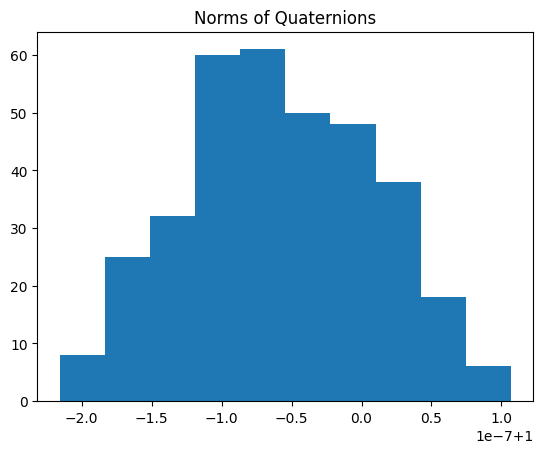

In [14]:
# check normalization of quats

norms = np.linalg.norm(quats, axis=1)

plt.hist(norms)
plt.title("Norms of Quaternions")
plt.show()

## Parse Clip Tracks to a More Convenience Format

Demo of a function -> implemented in src.utils

In [15]:
tracks = clip["animationClip"]["tracks"]

In [16]:
new_tracks = {}

for track in tracks:
    new_tracks[track["name"]] = {
        "type": track["type"],
        "times": track["times"],
        "values": track["values"],
    }

In [17]:
new_tracks.keys()

dict_keys(['Alex_body_1.morphTargetInfluences[19]', 'Alex_body_1.morphTargetInfluences[38]', 'Alex_body_1.morphTargetInfluences[41]', 'Alex_body_1.morphTargetInfluences[15]', 'Alex_body_1.morphTargetInfluences[17]', 'Alex_body_1.morphTargetInfluences[28]', 'Alex_body_1.morphTargetInfluences[27]', 'Alex_body_1.morphTargetInfluences[1]', 'Alex_body_1.morphTargetInfluences[8]', 'Alex_body_1.morphTargetInfluences[2]', 'Alex_body_1.morphTargetInfluences[48]', 'Alex_body_1.morphTargetInfluences[18]', 'Alex_body_1.morphTargetInfluences[23]', 'Alex_body_1.morphTargetInfluences[24]', 'Alex_body_1.morphTargetInfluences[36]', 'Alex_body_1.morphTargetInfluences[22]', 'Alex_body_1.morphTargetInfluences[37]', 'Alex_body_1.morphTargetInfluences[21]', 'Alex_body_1.morphTargetInfluences[35]', 'Alex_body_1.morphTargetInfluences[32]', 'Alex_body_1.morphTargetInfluences[20]', 'Alex_body_1.morphTargetInfluences[31]', 'Alex_body_1.morphTargetInfluences[34]', 'Alex_body_1.morphTargetInfluences[33]', 'Alex_bo

In [18]:
new_tracks['rootx.quaternion']["type"]

'quaternion'

In [19]:
from src.utils import parse_clip

test = parse_clip(clip)
test["animationClip"]["tracks"]["rootx.quaternion"]["values"]

KeyError: 'rootx.quaternion'

---
## Dictonary

In [ ]:
from pathlib import Path
import numpy as np
from src.utils import prepare_clip

data_path = Path("data/npz")
file_count = sum(1 for item in data_path.iterdir() if item.is_file())

for i in range(file_count):
    clip = np.load(f"{data_path}/clip_{i}.npz", allow_pickle=True)["clip"].item()
    clip, clip_name, quats = prepare_clip(clip)
    print(f"{i:<4} {clip_name:<30} {quats["rootx"].shape}")

0    test2-1725001324174            (1096, 4)
1    ขยัน-1725161180445             (403, 4)
2    วันนี้-1725161300887           (376, 4)
3    ฟัน-1725161607770              (333, 4)
4    ปวด(ฟัน)-1725161767928         (384, 4)
5    หายแล้ว (คำถาม)-1725162180375  (317, 4)
6    ยัง-1725162616466              (368, 4)
7    ยา-1725166718295               (433, 4)
8    กินยา(ยาเม็ด)-1725166870505    (453, 4)
9    ลดลง-1725167195129             (505, 4)
10   กลุ่ม-1725167526604            (163, 4)
11   แอพพลิเคชั่นไลน์ (Line)-1725167599842 (167, 4)
12   บอก(เรา)-1725167670329         (156, 4)
13   shoulderbug_nocoilpro-1725784055113 (671, 4)
14   allbody1_nocoilpro-1725784133154 (835, 4)
15   allbody2_nocoilpro-1725784195311 (692, 4)
16   face_nocoilpro-1725784317332   (615, 4)
17   eye_nocoilpro-1725784386680    (634, 4)
18   number_nocoilpro-1725784451467 (745, 4)
19   shoulderbug_coilpro-1725784600199 (700, 4)
20   allbody1_coilpro-1725784648556 (721, 4)
21   allbody2_coilpro-1725784699838